# MTA Service Reliability Analysis
## 04: Hourly Ridership Analysis

---
### Imports

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import PercentFormatter
import matplotlib.dates as mdates

import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
import statsmodels

import calplot
import seaborn as sns

---
### Load Data

This takes a little less than a minute because the dataset is large.

In [3]:
hourly = pd.read_csv(
    "../data/raw/hourly_ridership_select_months.csv"
)

hourly.columns.tolist()

['transit_timestamp',
 'transit_mode',
 'station_complex_id',
 'station_complex',
 'borough',
 'payment_method',
 'fare_class_category',
 'ridership',
 'transfers',
 'latitude',
 'longitude',
 'georeference']

In [4]:
hourly.head()

,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,georeference
0,2026-04-01T00:00:00.000,subway,438,"135 St (2,3)",Manhattan,omny,OMNY - Fair Fare,4.0,0.0,40.814228,-73.94077,POINT (-73.94077 40.814228)
1,2026-04-01T00:00:00.000,subway,268,"65 St (M,R)",Queens,omny,OMNY - Fair Fare,1.0,0.0,40.749670,-73.89845,POINT (-73.89845 40.74967)
2,2026-04-01T00:00:00.000,subway,164,"34 St-Penn Station (A,C,E)",Manhattan,omny,OMNY - Fair Fare,29.0,1.0,40.752290,-73.99339,POINT (-73.99339 40.75229)
3,2026-04-01T00:00:00.000,subway,192,Rockaway Blvd (A),Queens,omny,OMNY - Other,1.0,0.0,40.680428,-73.84386,POINT (-73.84386 40.680428)
4,2026-04-01T00:00:00.000,subway,213,"Fordham Rd (B,D)",Bronx,metrocard,Metrocard - Unlimited 30-Day,1.0,0.0,40.861298,-73.89775,POINT (-73.89775 40.861298)


In [5]:
hourly.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 5153761 entries, 0 to 5153760
Data columns (total 12 columns):
 #   Column               Dtype  
---  ------               -----  
 0   transit_timestamp    str    
 1   transit_mode         str    
 2   station_complex_id   str    
 3   station_complex      str    
 4   borough              str    
 5   payment_method       str    
 6   fare_class_category  str    
 7   ridership            float64
 8   transfers            float64
 9   latitude             float64
 10  longitude            float64
 11  georeference         str    
dtypes: float64(4), str(8)
memory usage: 2.5 GB


In [6]:
hourly.shape   # 5,153,761 rows!

(5153761, 12)

In [7]:
hourly.describe(include="all")

,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,georeference
count,5153761,5153761,5153761,5153761,5153761,5153761,5153761,5.153761e+06,5.153761e+06,5.153761e+06,5.153761e+06,5153761
unique,2184,3,428,428,5,2,12,NaN,NaN,NaN,NaN,428
top,2026-04-14T08:00:00.000,subway,611,"Times Sq-42 St/Port Authority Bus Terminal (1,...",Brooklyn,omny,OMNY - Full Fare,NaN,NaN,NaN,NaN,POINT (-73.98758 40.755745)
freq,3088,5118553,18106,18106,1813783,4086956,913096,NaN,NaN,NaN,NaN,18106
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.697361e+01,3.562264e+00,4.073321e+01,-7.393473e+01,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.097320e+02,2.387731e+01,7.846069e-02,5.623693e-02,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,-5.000000e+00,4.057613e+01,-7.407484e+01,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000e+00,0.000000e+00,4.067834e+01,-7.398123e+01,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000000e+00,0.000000e+00,4.072561e+01,-7.394550e+01,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.800000e+01,1.000000e+00,4.079502e+01,-7.389865e+01,NaN


---
### Data Cleaning and Feature Engineering

Count missing values.

In [8]:
hourly.isna().sum()

transit_timestamp      0
transit_mode           0
station_complex_id     0
station_complex        0
borough                0
payment_method         0
fare_class_category    0
ridership              0
transfers              0
latitude               0
longitude              0
georeference           0
dtype: int64

In [9]:
# See columns with only missing values.
hourly.isnull().sum()[hourly.isnull().sum() > 0]

Series([], dtype: int64)

None of the values are missing, which is great.

Check if any rows are duplicated.

In [10]:
hourly.duplicated().sum()

np.int64(0)

None of the values are duplicated.

In [11]:
hourly.nunique()   # Unique values in each column

transit_timestamp      2184
transit_mode              3
station_complex_id      428
station_complex         428
borough                   5
payment_method            2
fare_class_category      12
ridership              7362
transfers              1279
latitude                427
longitude               425
georeference            428
dtype: int64

Create new columns from the timestamp for easier analysis later.

In [12]:
hourly["transit_timestamp"] = pd.to_datetime(hourly["transit_timestamp"])

hourly["date"] = hourly["transit_timestamp"].dt.date
hourly["hour"] = hourly["transit_timestamp"].dt.hour
hourly["weekday"] = hourly["transit_timestamp"].dt.day_name()
hourly["month"] = hourly["transit_timestamp"].dt.month_name()
hourly["year"] = hourly["transit_timestamp"].dt.year
hourly["day"] = hourly["transit_timestamp"].dt.day
hourly["week"] = hourly["transit_timestamp"].dt.isocalendar().week

hourly.head()

,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,georeference,date,hour,weekday,month,year,day,week
0,2026-04-01,subway,438,"135 St (2,3)",Manhattan,omny,OMNY - Fair Fare,4.0,0.0,40.814228,-73.94077,POINT (-73.94077 40.814228),2026-04-01,0,Wednesday,April,2026,1,14
1,2026-04-01,subway,268,"65 St (M,R)",Queens,omny,OMNY - Fair Fare,1.0,0.0,40.749670,-73.89845,POINT (-73.89845 40.74967),2026-04-01,0,Wednesday,April,2026,1,14
2,2026-04-01,subway,164,"34 St-Penn Station (A,C,E)",Manhattan,omny,OMNY - Fair Fare,29.0,1.0,40.752290,-73.99339,POINT (-73.99339 40.75229),2026-04-01,0,Wednesday,April,2026,1,14
3,2026-04-01,subway,192,Rockaway Blvd (A),Queens,omny,OMNY - Other,1.0,0.0,40.680428,-73.84386,POINT (-73.84386 40.680428),2026-04-01,0,Wednesday,April,2026,1,14
4,2026-04-01,subway,213,"Fordham Rd (B,D)",Bronx,metrocard,Metrocard - Unlimited 30-Day,1.0,0.0,40.861298,-73.89775,POINT (-73.89775 40.861298),2026-04-01,0,Wednesday,April,2026,1,14


---
### Exploratory Data Analysis

In [13]:
hourly["borough"].unique()

<StringArray>
['Manhattan', 'Queens', 'Bronx', 'Brooklyn', 'Staten Island']
Length: 5, dtype: str

In [14]:
hourly["payment_method"].value_counts()

payment_method
omny         4086956
metrocard    1066805
Name: count, dtype: int64

In [15]:
hourly["fare_class_category"].value_counts()

fare_class_category
OMNY - Full Fare                    913096
OMNY - Fair Fare                    813093
OMNY - Students                     797158
OMNY - Seniors & Disability         793316
OMNY - Other                        770293
Metrocard - Other                   627437
Metrocard - Unlimited 30-Day        256162
Metrocard - Unlimited 7-Day          81374
Metrocard - Seniors & Disability     54345
Metrocard - Full Fare                47390
Metrocard - Fair Fare                   83
Metrocard - Students                    14
Name: count, dtype: int64

In [16]:
hourly["transit_mode"].value_counts()

transit_mode
subway                   5118553
staten_island_railway      19630
tram                       15578
Name: count, dtype: int64

Top 3 Largest Stations (by number of observations):

* Times Sq - 42 St
* 34 St-Herald Sq
* Flushing-Main St

In [17]:
hourly["station_complex"].value_counts().head(20)

station_complex
Times Sq-42 St/Port Authority Bus Terminal (1,2,3,7,A,C,E,N,Q,R,W,S)    18106
34 St-Herald Sq (B,D,F,M,N,Q,R,W)                                       16876
Flushing-Main St (7)                                                    16537
Grand Central-42 St (4,5,6,7,S)                                         16504
14 St-Union Sq (4,5,6,L,N,Q,R,W)                                        16455
Jamaica Center-Parsons/Archer (E,J,Z)                                   16148
Fulton St (2,3,4,5,A,C,J,Z)                                             16143
34 St-Penn Station (1,2,3)                                              16061
Sutphin Blvd-Archer Av-JFK Airport (E,J,Z)                              15978
Jackson Hts-Roosevelt Av/74 St-Broadway (7,E,F,M,R)                     15976
34 St-Penn Station (A,C,E)                                              15962
161 St-Yankee Stadium (4,B,D)                                           15631
125 St (4,5,6)                                  

In [18]:
hourly["borough"].value_counts()

borough
Brooklyn         1813783
Manhattan        1575941
Queens            913314
Bronx             831093
Staten Island      19630
Name: count, dtype: int64

The most hourly observations happened in Brooklyn and Manhattan, suggesting there are more subway lines there.

Due to the large size, the dataset covers April, May, June 2026 only.

In [19]:
hourly["transit_timestamp"].min()

Timestamp('2026-04-01 00:00:00')

In [20]:
hourly["transit_timestamp"].max()

Timestamp('2026-06-30 23:00:00')

In [21]:
hourly["ridership"].describe()

count    5.153761e+06
mean     6.697361e+01
std      3.097320e+02
min      1.000000e+00
25%      2.000000e+00
50%      8.000000e+00
75%      2.800000e+01
max      2.187800e+04
Name: ridership, dtype: float64

In [22]:
hourly["transfers"].describe()

count    5.153761e+06
mean     3.562264e+00
std      2.387731e+01
min     -5.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      2.556000e+03
Name: transfers, dtype: float64

The minimum transer is negative. A possible explanation: some transfers were overcounted before so the data is corrected with negative values.

In [28]:
hourly[hourly["transfers"] < 0]

,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,georeference,date,hour,weekday,month,year,day,week
2685291,2026-05-17 18:00:00,subway,629,"Metropolitan Av/Lorimer St (G,L)",Brooklyn,omny,OMNY - Fair Fare,23.0,-1.0,40.713430,-73.950840,POINT (-73.95084 40.71343),2026-05-17,18,Sunday,May,2026,17,20
2986965,2026-05-22 21:00:00,subway,204,Beach 67 St (A),Queens,omny,OMNY - Full Fare,23.0,-2.0,40.590927,-73.796920,POINT (-73.79692 40.590927),2026-05-22,21,Friday,May,2026,22,21
3105275,2026-05-25 07:00:00,subway,601,"14 St/6 Av (1,2,3,L,F,M)",Manhattan,omny,OMNY - Other,10.0,-1.0,40.737797,-73.997734,POINT (-73.997734 40.737797),2026-05-25,7,Monday,May,2026,25,22
3105326,2026-05-25 07:00:00,subway,83,"Woodhaven Blvd (J,Z)",Queens,omny,OMNY - Seniors & Disability,6.0,-1.0,40.693880,-73.851580,POINT (-73.85158 40.69388),2026-05-25,7,Monday,May,2026,25,22
3190346,2026-05-26 18:00:00,subway,601,"14 St/6 Av (1,2,3,L,F,M)",Manhattan,omny,OMNY - Fair Fare,93.0,-2.0,40.737797,-73.997734,POINT (-73.997734 40.737797),2026-05-26,18,Tuesday,May,2026,26,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5032782,2026-06-28 16:00:00,subway,601,"14 St/6 Av (1,2,3,L,F,M)",Manhattan,omny,OMNY - Full Fare,4819.0,-5.0,40.737797,-73.997734,POINT (-73.997734 40.737797),2026-06-28,16,Sunday,June,2026,28,26
5036572,2026-06-28 18:00:00,subway,601,"14 St/6 Av (1,2,3,L,F,M)",Manhattan,omny,OMNY - Full Fare,3148.0,-1.0,40.737797,-73.997734,POINT (-73.997734 40.737797),2026-06-28,18,Sunday,June,2026,28,26
5045185,2026-06-28 21:00:00,subway,601,"14 St/6 Av (1,2,3,L,F,M)",Manhattan,omny,OMNY - Fair Fare,57.0,-1.0,40.737797,-73.997734,POINT (-73.997734 40.737797),2026-06-28,21,Sunday,June,2026,28,26
5077060,2026-06-29 12:00:00,subway,204,Beach 67 St (A),Queens,omny,OMNY - Seniors & Disability,6.0,-1.0,40.590927,-73.796920,POINT (-73.79692 40.590927),2026-06-29,12,Monday,June,2026,29,27


In [23]:
hourly[["ridership","transfers"]].corr()

,ridership,transfers
ridership,1.000000,0.368338
transfers,0.368338,1.000000


Top 3 Largest Stations (by ridership numbers):

* Times Sq - 42 St
* Gran Central - 42 St
* 34 St-Herald Sq

In [24]:
(
    hourly
    .groupby("station_complex")["ridership"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

station_complex
Times Sq-42 St/Port Authority Bus Terminal (1,2,3,7,A,C,E,N,Q,R,W,S)    12658531.0
Grand Central-42 St (4,5,6,7,S)                                          9646217.0
34 St-Herald Sq (B,D,F,M,N,Q,R,W)                                        6986562.0
14 St-Union Sq (4,5,6,L,N,Q,R,W)                                         6483943.0
34 St-Penn Station (A,C,E)                                               5603355.0
Fulton St (2,3,4,5,A,C,J,Z)                                              5154223.0
34 St-Penn Station (1,2,3)                                               4745884.0
59 St-Columbus Circle (1,A,C,B,D)                                        4559982.0
Jackson Hts-Roosevelt Av/74 St-Broadway (7,E,F,M,R)                      4002444.0
Flushing-Main St (7)                                                     3926173.0
Lexington Av/51-53 Sts (6,E,F)                                           3760319.0
Chambers St/WTC/Park Place/Cortlandt St (2,3,A,C,E,R,W)                

Interestingly enough, there was more ridership in Brooklyn than Manhattan. It makes sense because the top 3 largest stations by ridership numbers are located in Manhattan.

In [25]:
(
    hourly
    .groupby("borough")["ridership"]
    .sum()
    .sort_values(ascending=False)
)

borough
Manhattan        193460663.0
Brooklyn          77359305.0
Queens            50446037.0
Bronx             23312663.0
Staten Island       587331.0
Name: ridership, dtype: float64

The peak hours are 7-9 AM and 2-6 PM.

In [26]:
(
    hourly
    .groupby("hour")["ridership"]
    .sum()
)

hour
0      3387755.0
1      1481858.0
2       890442.0
3       833052.0
4      1740973.0
5      5284684.0
6     11426867.0
7     21336351.0
8     27423309.0
9     19414026.0
10    14774392.0
11    14708279.0
12    15882180.0
13    17591559.0
14    20712135.0
15    24408574.0
16    27753672.0
17    32474078.0
18    25337064.0
19    17600756.0
20    13663050.0
21    11575727.0
22     9378082.0
23     6087134.0
Name: ridership, dtype: float64

As expected, the weekend has lower ridership.

In [27]:
(
    hourly
    .groupby("weekday")["ridership"]
    .sum()
)

weekday
Friday       53219521.0
Monday       50499123.0
Saturday     38096797.0
Sunday       30197761.0
Thursday     57819479.0
Tuesday      57316155.0
Wednesday    58017163.0
Name: ridership, dtype: float64

Let's plot the data.

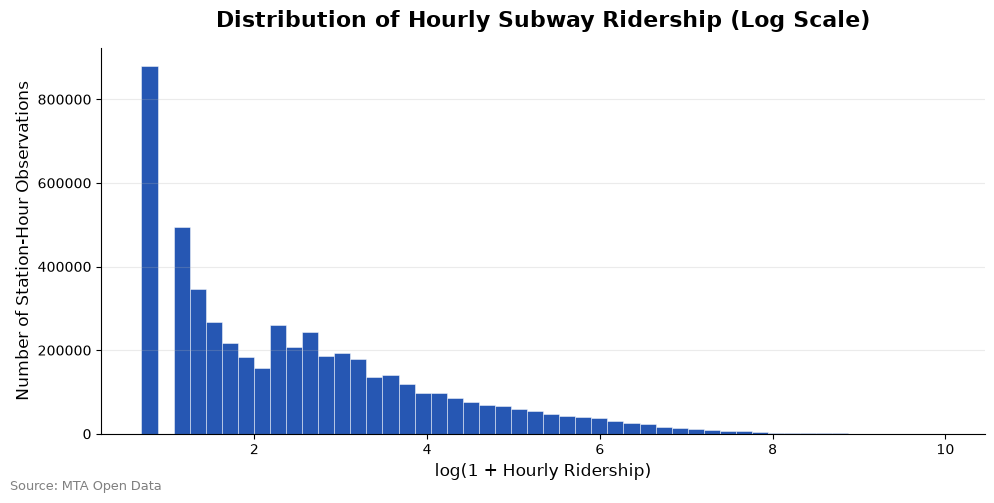

In [46]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    np.log1p(hourly["ridership"]),
    bins=50,
    color="#0039A6",
    edgecolor="white",
    linewidth=0.4,
    alpha=0.85
)

ax.set_title(
    "Distribution of Hourly Subway Ridership (Log Scale)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("log(1 + Hourly Ridership)", fontsize=12)
ax.set_ylabel("Number of Station-Hour Observations", fontsize=12)

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.figtext(
    0.01,
    0.01,
    "Source: MTA Open Data",
    fontsize=9,
    color="gray"
)

plt.tight_layout()
plt.show()

In [32]:
hourly["ridership"].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999])

0.500       8.00
0.750      28.00
0.900     117.00
0.950     280.00
0.990    1095.00
0.999    4165.24
Name: ridership, dtype: float64

In [33]:
hourly["ridership"].nlargest(10)

4758986    21878.0
4033658    21799.0
3977250    21184.0
3581935    20894.0
3639007    20563.0
1194031    20243.0
4814369    20214.0
4430517    20161.0
2053373    20157.0
2396189    20035.0
Name: ridership, dtype: float64

**Insight:**

Hourly subway ridership is highly concentrated. While the median station-hour records only 8 riders, the busiest 1% exceed 1,095 riders and the maximum observation reaches nearly 22,000 riders in a single hour. This large gap indicates a heavily right-skewed distribution, where a small number of busy stations and peak commuting periods account for a disproportionate share of total ridership.

In [34]:
hourly.nlargest(
    10,
    "ridership"
)[[
    "transit_timestamp",
    "station_complex",
    "borough",
    "ridership",
    "transfers",
    "fare_class_category"
]]

,transit_timestamp,station_complex,borough,ridership,transfers,fare_class_category
4758986,2026-06-23 17:00:00,"Grand Central-42 St (4,5,6,7,S)",Manhattan,21878.0,115.0,OMNY - Full Fare
4033658,2026-06-10 17:00:00,"Grand Central-42 St (4,5,6,7,S)",Manhattan,21799.0,66.0,OMNY - Full Fare
3977250,2026-06-09 17:00:00,"Grand Central-42 St (4,5,6,7,S)",Manhattan,21184.0,94.0,OMNY - Full Fare
3581935,2026-06-02 17:00:00,"Grand Central-42 St (4,5,6,7,S)",Manhattan,20894.0,82.0,OMNY - Full Fare
3639007,2026-06-03 17:00:00,"Grand Central-42 St (4,5,6,7,S)",Manhattan,20563.0,83.0,OMNY - Full Fare
1194031,2026-04-21 17:00:00,"Grand Central-42 St (4,5,6,7,S)",Manhattan,20243.0,102.0,OMNY - Full Fare
4814369,2026-06-24 17:00:00,"Grand Central-42 St (4,5,6,7,S)",Manhattan,20214.0,96.0,OMNY - Full Fare
4430517,2026-06-17 17:00:00,"Grand Central-42 St (4,5,6,7,S)",Manhattan,20161.0,86.0,OMNY - Full Fare
2053373,2026-05-06 17:00:00,"Grand Central-42 St (4,5,6,7,S)",Manhattan,20157.0,79.0,OMNY - Full Fare
2396189,2026-05-12 17:00:00,"Grand Central-42 St (4,5,6,7,S)",Manhattan,20035.0,96.0,OMNY - Full Fare


In [44]:
hourly[(hourly["transit_timestamp"] == "2026-06-23 8:00:00") & (hourly["station_complex"] == "Grand Central-42 St (4,5,6,7,S)")]

,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,georeference,date,hour,weekday,month,year,day,week
4732209,2026-06-23 08:00:00,subway,610,"Grand Central-42 St (4,5,6,7,S)",Manhattan,metrocard,Metrocard - Unlimited 30-Day,5.0,0.0,40.75199,-73.977356,POINT (-73.977356 40.75199),2026-06-23,8,Tuesday,June,2026,23,26
4732342,2026-06-23 08:00:00,subway,610,"Grand Central-42 St (4,5,6,7,S)",Manhattan,metrocard,Metrocard - Unlimited 7-Day,1.0,0.0,40.75199,-73.977356,POINT (-73.977356 40.75199),2026-06-23,8,Tuesday,June,2026,23,26
4732507,2026-06-23 08:00:00,subway,610,"Grand Central-42 St (4,5,6,7,S)",Manhattan,omny,OMNY - Full Fare,12735.0,216.0,40.75199,-73.977356,POINT (-73.977356 40.75199),2026-06-23,8,Tuesday,June,2026,23,26
4733049,2026-06-23 08:00:00,subway,610,"Grand Central-42 St (4,5,6,7,S)",Manhattan,omny,OMNY - Fair Fare,81.0,7.0,40.75199,-73.977356,POINT (-73.977356 40.75199),2026-06-23,8,Tuesday,June,2026,23,26
4733305,2026-06-23 08:00:00,subway,610,"Grand Central-42 St (4,5,6,7,S)",Manhattan,metrocard,Metrocard - Other,35.0,0.0,40.75199,-73.977356,POINT (-73.977356 40.75199),2026-06-23,8,Tuesday,June,2026,23,26
4733413,2026-06-23 08:00:00,subway,610,"Grand Central-42 St (4,5,6,7,S)",Manhattan,omny,OMNY - Students,83.0,2.0,40.75199,-73.977356,POINT (-73.977356 40.75199),2026-06-23,8,Tuesday,June,2026,23,26
4733743,2026-06-23 08:00:00,subway,610,"Grand Central-42 St (4,5,6,7,S)",Manhattan,omny,OMNY - Other,186.0,0.0,40.75199,-73.977356,POINT (-73.977356 40.75199),2026-06-23,8,Tuesday,June,2026,23,26
4733856,2026-06-23 08:00:00,subway,610,"Grand Central-42 St (4,5,6,7,S)",Manhattan,omny,OMNY - Seniors & Disability,345.0,15.0,40.75199,-73.977356,POINT (-73.977356 40.75199),2026-06-23,8,Tuesday,June,2026,23,26
4733875,2026-06-23 08:00:00,subway,610,"Grand Central-42 St (4,5,6,7,S)",Manhattan,metrocard,Metrocard - Full Fare,1.0,0.0,40.75199,-73.977356,POINT (-73.977356 40.75199),2026-06-23,8,Tuesday,June,2026,23,26


For each station and hour, there are multiple entries that specify the number of riders using different payment methods.

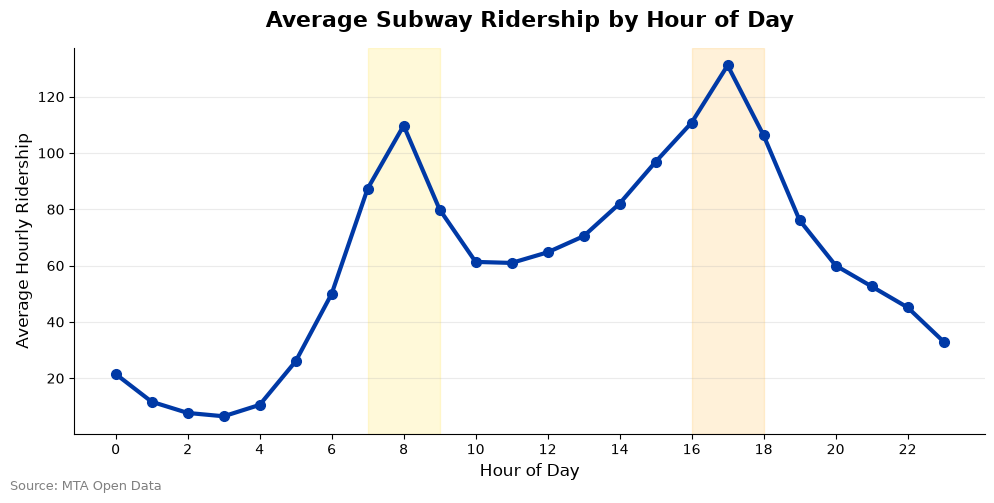

In [56]:
hourly_by_hour = (
    hourly.groupby("hour")["ridership"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(
    hourly_by_hour.index,
    hourly_by_hour.values,
    marker="o",
    linewidth=3,
    markersize=7,
    color="#0039A6"
)

# Highlight morning peak
ax.axvspan(7, 9, color="gold", alpha=0.15)

# Highlight evening peak
ax.axvspan(16, 18, color="orange", alpha=0.15)

ax.set_title(
    "Average Subway Ridership by Hour of Day",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Hour of Day", fontsize=12)
ax.set_ylabel("Average Hourly Ridership", fontsize=12)

ax.set_xticks(range(0,24,2))

ax.grid(axis="y", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.figtext(
    0.01,
    0.01,
    "Source: MTA Open Data",
    fontsize=9,
    color="gray"
)

plt.tight_layout()
plt.show()

**Insight:**

Average subway ridership follows a clear bimodal commuting pattern. Ridership is lowest between 2 AM and 4 AM, increases rapidly during the morning commute with a peak around 8 AM, and reaches an even higher peak around 5 PM, reflecting evening commuters returning home. The gradual decline after 6 PM suggests demand remains elevated into the evening before tapering off overnight.

The evening peak might be higher than the morning peak because of additional travel that commuters have outside of work, like dining, grocery shopping, etc.

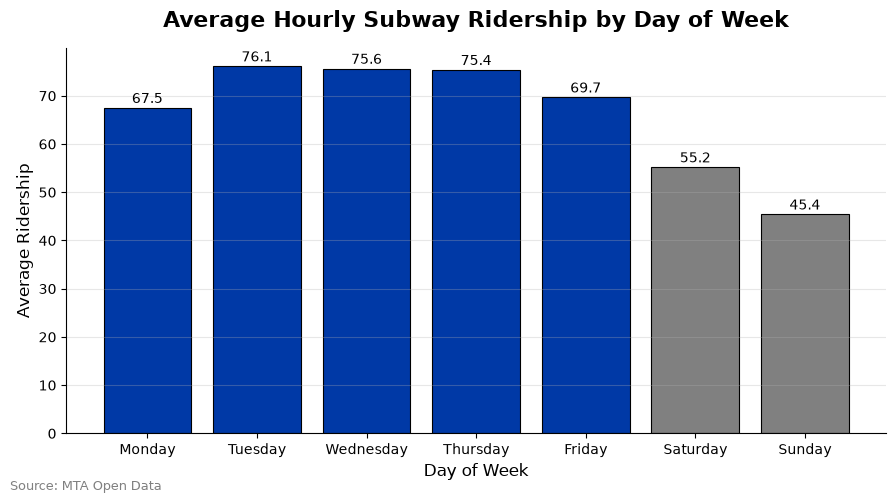

In [58]:
weekday_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

weekday = (
    hourly.groupby("weekday")["ridership"]
    .mean()
    .reindex(weekday_order)
)

colors = [
    "#0039A6", "#0039A6", "#0039A6",
    "#0039A6", "#0039A6",
    "gray", "gray"
]

fig, ax = plt.subplots(figsize=(9,5))

bars = ax.bar(
    weekday.index,
    weekday.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

# Labels above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}",
        ha="center",
        fontsize=10
    )

ax.set_title(
    "Average Hourly Subway Ridership by Day of Week",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Average Ridership", fontsize=12)
ax.set_xlabel("Day of Week", fontsize=12)

ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.figtext(
    0.01,
    0.01,
    "Source: MTA Open Data",
    fontsize=9,
    color="gray"
)

plt.tight_layout()
plt.show()

**Insight:**

Average hourly ridership is highest from Tuesday through Thursday, indicating consistent weekday commuting demand. Ridership declines slightly on Monday and Friday, and drops substantially on the weekend, with Sunday recording the lowest average ridership. This pattern reflects the dominance of work-related travel during weekdays and reduced commuting activity on weekends.

The ridership might be lower on Mondays and Fridays because some employees work remotely on those days. Also, 9-5 workers usually prefer to take 3-4 day weekends to travel or rest.

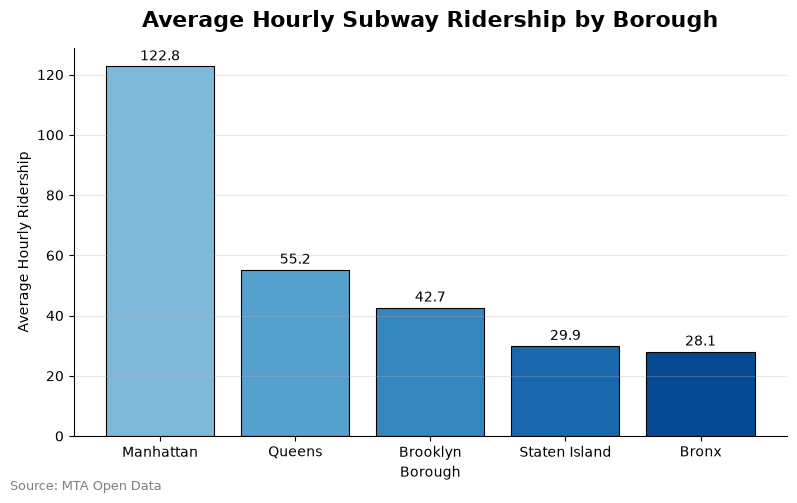

In [61]:
borough = (
    hourly.groupby("borough")["ridership"]
    .mean()
    .sort_values(ascending=False)
)
import matplotlib.pyplot as plt
import numpy as np

colors = plt.cm.Blues(np.linspace(0.45, 0.9, len(borough)))

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    borough.index,
    borough.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

# Value labels
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 2,
        f"{h:.1f}",
        ha="center",
        fontsize=10
    )

ax.set_title(
    "Average Hourly Subway Ridership by Borough",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Average Hourly Ridership")
ax.set_xlabel("Borough")

ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.figtext(
    0.01,
    0.01,
    "Source: MTA Open Data",
    fontsize=9,
    color="gray"
)

plt.tight_layout()
plt.show()

**Insight:**

Manhattan records by far the highest average hourly ridership, more than twice that of any other borough. This is expected because it serves as New York City’s primary business district and the destination for a large share of commuter trips. Queens and Brooklyn follow with moderate ridership, while Staten Island and the Bronx have the lowest average hourly station entries.

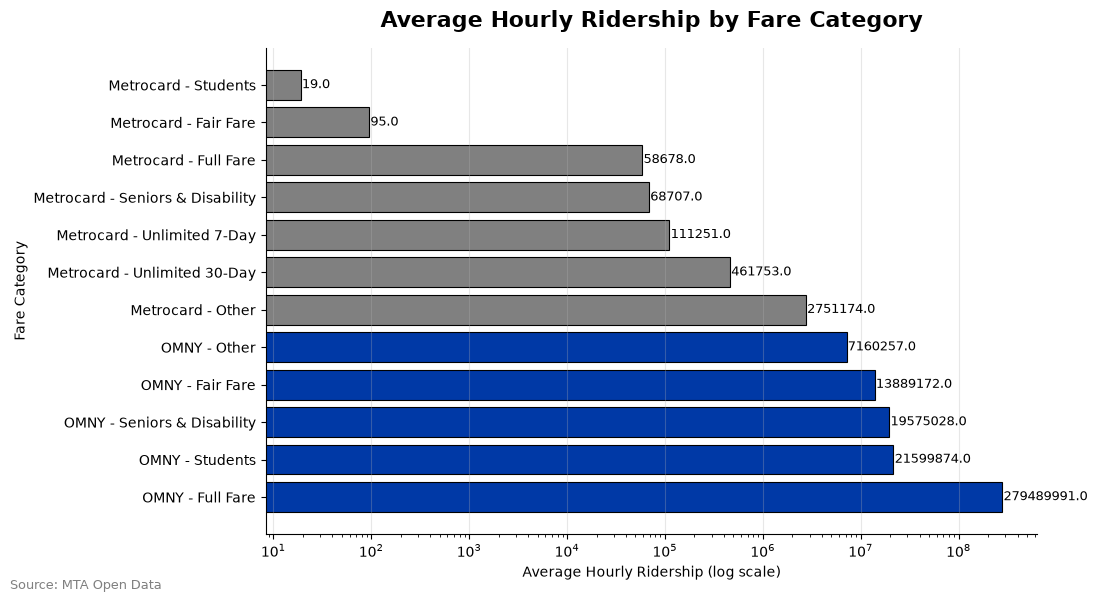

In [66]:
fare = (
    hourly.groupby("fare_class_category")["ridership"]
    .sum()
    .sort_values(ascending=False)
)

colors = []

for c in fare.index:
    if c.startswith("OMNY"):
        colors.append("#0039A6")
    else:
        colors.append("gray")

fig, ax = plt.subplots(figsize=(11,6))

bars = ax.barh(
    fare.index,
    fare.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

for bar in bars:
    w = bar.get_width()
    ax.text(
        w * 1.03,
        bar.get_y() + bar.get_height()/2,
        f"{w:.1f}",
        va="center",
        fontsize=9
    )

ax.set_xscale("log")

ax.set_title(
    "Average Hourly Ridership by Fare Category",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Average Hourly Ridership (log scale)")
ax.set_ylabel("Fare Category")

ax.grid(axis="x", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.figtext(
    0.01,
    0.01,
    "Source: MTA Open Data",
    fontsize=9,
    color="gray"
)

plt.tight_layout()
plt.show()

In [67]:
hourly["date"].min(), hourly["date"].max()

(datetime.date(2026, 4, 1), datetime.date(2026, 6, 30))

In [68]:
hourly["year"].value_counts().sort_index()

year
2026    5153761
Name: count, dtype: int64

In [69]:
pd.pivot_table(
    hourly,
    index="year",
    columns="fare_class_category",
    values="ridership",
    aggfunc="sum"
)

fare_class_category,Metrocard - Fair Fare,Metrocard - Full Fare,Metrocard - Other,Metrocard - Seniors & Disability,Metrocard - Students,Metrocard - Unlimited 30-Day,Metrocard - Unlimited 7-Day,OMNY - Fair Fare,OMNY - Full Fare,OMNY - Other,OMNY - Seniors & Disability,OMNY - Students
year,,,,,,,,,,,,
2026,95.0,58678.0,2751174.0,68707.0,19.0,461753.0,111251.0,13889172.0,279489991.0,7160257.0,19575028.0,21599874.0


In [70]:
pd.crosstab(
    hourly["payment_method"],
    hourly["fare_class_category"]
)

fare_class_category,Metrocard - Fair Fare,Metrocard - Full Fare,Metrocard - Other,Metrocard - Seniors & Disability,Metrocard - Students,Metrocard - Unlimited 30-Day,Metrocard - Unlimited 7-Day,OMNY - Fair Fare,OMNY - Full Fare,OMNY - Other,OMNY - Seniors & Disability,OMNY - Students
payment_method,,,,,,,,,,,,
metrocard,83,47390,627437,54345,14,256162,81374,0,0,0,0,0
omny,0,0,0,0,0,0,0,813093,913096,770293,793316,797158


In [71]:
payment = (
    hourly.groupby("payment_method")["ridership"]
    .sum()
)

payment

payment_method
metrocard      3451677.0
omny         341714322.0
Name: ridership, dtype: float64

In [72]:
payment / payment.sum()

payment_method
metrocard    0.01
omny         0.99
Name: ridership, dtype: float64

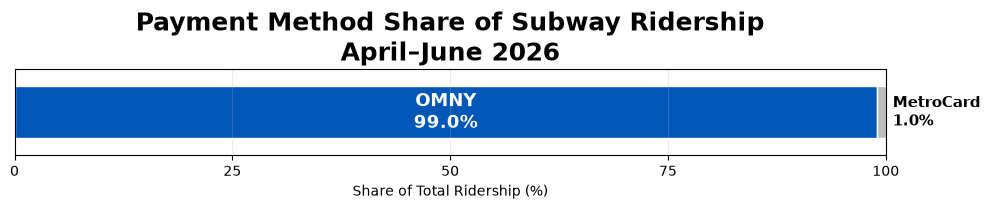

In [79]:
payment_pct = (payment / payment.sum() * 100).reindex(["omny", "metrocard"])

fig, ax = plt.subplots(figsize=(10, 2.2))

colors = ["#0057B8", "#BDBDBD"]  # OMNY, MetroCard

left = 0

for value, color, label in zip(
    payment_pct.values,
    colors,
    ["OMNY", "MetroCard"]
):
    ax.barh(
        y=0,       
        width=value,
        left=left,
        color=color,
        edgecolor="white",
        height=0.6,
    )

    if value > 5:
        ax.text(
            left + value/2,
            0,
            f"{label}\n{value:.1f}%",
            ha="center",
            va="center",
            color="white",
            fontsize=13,
            fontweight="bold",
        )
    else:
        ax.text(
            left + value + 0.8,
            0,
            f"{label}\n{value:.1f}%",
            ha="left",
            va="center",
            fontsize=11,
            fontweight="bold",
        )

    left += value

ax.set_xlim(0, 100)
ax.set_ylim(-0.5, 0.5)
ax.set_yticks([])
ax.set_xlabel("Share of Total Ridership (%)")
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_title("Payment Method Share of Subway Ridership\nApril–June 2026",
             fontsize=18,
             fontweight="bold")

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

**Insight:**

MetroCard was discontinued for new sales and reloads in December 2025. Despite this, approximately 1% of recorded rides between April and June 2026 were still paid using MetroCard. This is consistent with riders continuing to use previously loaded cards or remaining balances during the transition to OMNY

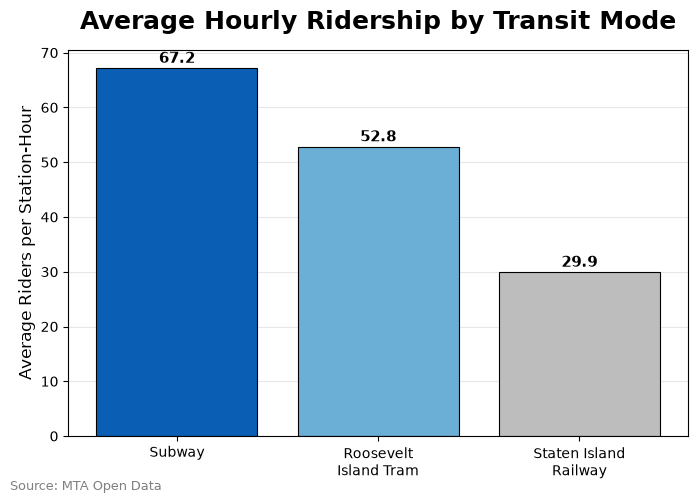

In [80]:
mode = (
    hourly.groupby("transit_mode")["ridership"]
    .mean()
    .sort_values(ascending=False)
)

labels = {
    "subway": "Subway",
    "tram": "Roosevelt\nIsland Tram",
    "staten_island_railway": "Staten Island\nRailway"
}

mode.index = [labels[i] for i in mode.index]

plt.figure(figsize=(7,5))

bars = plt.bar(
    mode.index,
    mode.values,
    color=["#0A5FB4", "#6BAED6", "#BDBDBD"],
    edgecolor="black",
    linewidth=0.8
)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 1,
        f"{h:.1f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Average Hourly Ridership by Transit Mode",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.ylabel("Average Riders per Station-Hour", fontsize=12)
plt.xlabel("")
plt.grid(axis="y", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.figtext(
    0.01,
    0.01,
    "Source: MTA Open Data",
    fontsize=9,
    color="gray"
)

plt.tight_layout()
plt.show()

**Insight:**

The subway records the highest average ridership per station-hour (~67 riders), followed by the Roosevelt Island Tram (~53), while the Staten Island Railway averages approximately 30 riders. Although the subway dominates overall usage, the tram exhibits relatively high utilization despite having only a small number of stations.

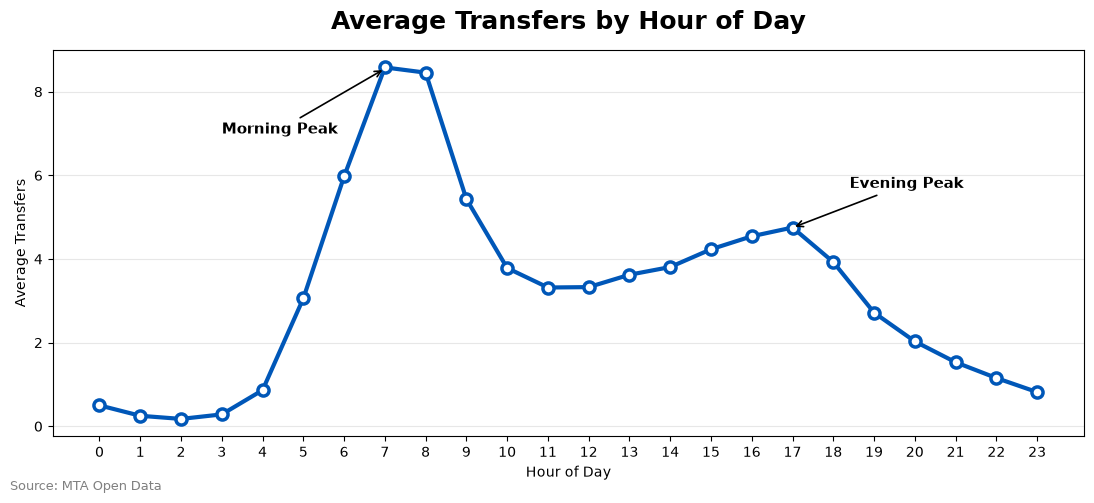

In [88]:
hourly_transfer = (
    hourly.groupby("hour")["transfers"]
    .mean()
)

plt.figure(figsize=(11,5))

plt.plot(
    hourly_transfer.index,
    hourly_transfer.values,
    color="#0057B8",
    linewidth=3,
    marker="o",
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2.5
)

plt.annotate(
    "Morning Peak",
    xy=(7, 8.55),
    xytext=(3, 7),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=11,
    fontweight="bold"
)

plt.annotate(
    "Evening Peak",
    xy=(17, 4.75),
    xytext=(18.4, 5.7),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=11,
    fontweight="bold"
)

plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

plt.title(
    "Average Transfers by Hour of Day",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Transfers")

plt.figtext(
    0.01,
    0.01,
    "Source: MTA Open Data",
    fontsize=9,
    color="gray"
)

plt.tight_layout()
plt.show()

**Insight:**

Average transfers peak during the morning commute (7–8 AM), reaching approximately 8.6 transfers per station-hour, with a smaller secondary peak around 5 PM. The sharper morning peak suggests commuters are more likely to transfer between subway lines when traveling to work, whereas evening travel appears more distributed across routes and times.

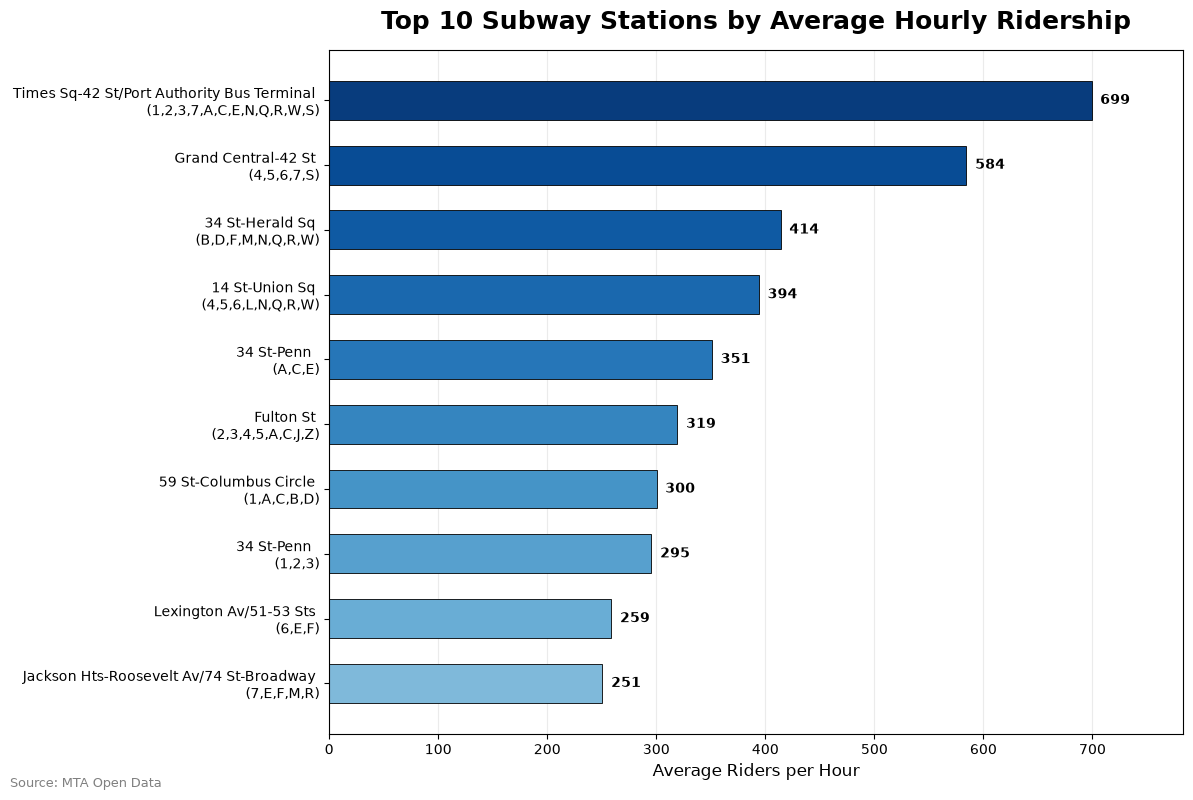

In [100]:
# Top 10 stations by average hourly ridership
top = (
    hourly.groupby("station_complex")["ridership"]
    .mean()
    .nlargest(10)
    .sort_values()  # smallest at top, largest at bottom
)

# Remove subway line names in parentheses
top.index = (
    top.index
    .str.replace("Station", "", regex=False)
    .str.replace("(", "\n(", regex=False)
)

# Blue gradient
colors = plt.cm.Blues(np.linspace(0.45, 0.95, len(top)))

plt.figure(figsize=(12, 8))

bars = plt.barh(
    top.index,
    top.values,
    color=colors,
    edgecolor="black",
    linewidth=0.6,
    height=0.6
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 8,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Top 10 Subway Stations by Average Hourly Ridership",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Average Riders per Hour", fontsize=12)
plt.ylabel("")

plt.grid(axis="x", alpha=0.25)
plt.gca().set_axisbelow(True)

# Add a little room for the labels
plt.xlim(0, top.max() * 1.12)

plt.figtext(
    0.01,
    0.01,
    "Source: MTA Open Data",
    fontsize=9,
    color="gray"
)

plt.tight_layout()
plt.show()

**Insight:**

Average hourly ridership is highly concentrated at large transfer hubs. Times Square–42 St/Port Authority Bus Terminal records the highest average hourly ridership (~699 riders/hour), followed by Grand Central–42 St (~584 riders/hour). These stations serve multiple subway lines and connect to other transportation services, making them major passenger distribution centers.

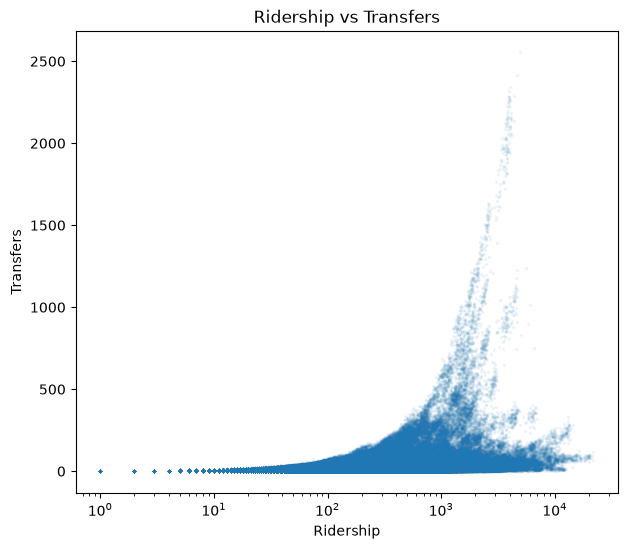

In [54]:
plt.figure(figsize=(7,6))

plt.scatter(
    hourly["ridership"],
    hourly["transfers"],
    alpha=0.05,
    s=2
)

plt.xscale("log")

plt.title("Ridership vs Transfers")
plt.xlabel("Ridership")
plt.ylabel("Transfers")

plt.show()

**Insight:**

 Ridership and transfers exhibit a moderate positive relationship (Pearson correlation = 0.37). While higher-ridership stations generally have more transfers, the large spread at high ridership levels indicates that transfer volume also depends on the station’s role as a transit hub rather than ridership alone.

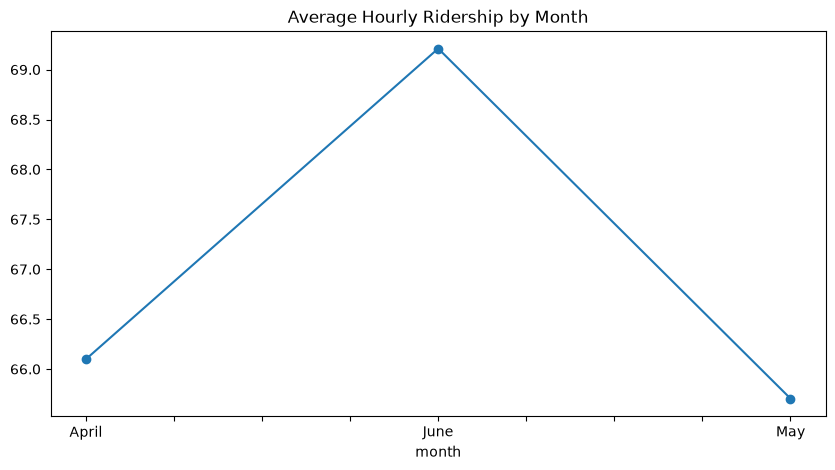

In [55]:
monthly = (
    hourly.groupby("month")["ridership"]
    .mean()
)

monthly.plot(figsize=(10,5), marker="o")

plt.title("Average Hourly Ridership by Month")
plt.show()